# Подбор весов комбинированной модели

В `exp02_baseline.ipynb` веса 0.7 / 0.3 (структура / TF-IDF) выбраны интуитивно.
Здесь перебираем `struct_weight` от 0.1 до 0.9 и выбираем значение по данным.

**Целевая метрика:** Category Hit Rate@5 — основной сигнал качества для задачи.
Coverage используем как ограничение: = 1.0 (каждый тур хотя бы раз появляется в рекомендациях).

---
## 1. Данные и признаки

In [10]:
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

sys.path.insert(0, str(Path("..").resolve()))
from src.models.features import build_feature_matrices
from src.models.metrics import category_hit_rate, catalog_coverage, mean_similarity, intra_list_diversity
from src.models.recommender import get_similar_tours

DATA_PATH = Path("../data/tours.json")
ARTIFACTS = Path("../artifacts/exp03")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

In [11]:
with open(DATA_PATH, encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
df = df[df["status"] == "active"].reset_index(drop=True)
print(f"Активных туров: {len(df)}")

Активных туров: 170


In [12]:
struct_matrix, tfidf_matrix, scaler, tfidf = build_feature_matrices(df)
print(f"struct_matrix: {struct_matrix.shape}")
print(f"tfidf_matrix:  {tfidf_matrix.shape}")

struct_matrix: (170, 19)
tfidf_matrix:  (170, 200)


---
## 2. Метрики

`category_hit_rate`, `catalog_coverage`, `mean_similarity`, `intra_list_diversity` импортированы из `src.models.metrics`.

---
## 3. Grid search по struct_weight

In [13]:
TOP_K = 5
weights = np.round(np.arange(0.1, 1.0, 0.1), 1)

sim_struct = cosine_similarity(struct_matrix)
sim_tfidf  = cosine_similarity(tfidf_matrix)

records = []
for w in weights:
    sim = w * sim_struct + (1 - w) * sim_tfidf
    records.append({
        "struct_weight": w,
        "CHR@5":         category_hit_rate(df, sim, TOP_K),
        "Coverage":      catalog_coverage(sim, TOP_K),
        "MeanSim@5":     mean_similarity(sim, TOP_K),
        "ILD@5":         intra_list_diversity(sim, TOP_K),
    })

grid_df = pd.DataFrame(records).set_index("struct_weight")
display(grid_df.round(3))

,CHR@5,Coverage,MeanSim@5,ILD@5
struct_weight,,,,
0.1,0.788,0.994,0.455,0.672
0.2,0.846,0.988,0.489,0.633
0.3,0.894,0.988,0.527,0.585
0.4,0.920,1.000,0.569,0.531
0.5,0.928,1.000,0.615,0.477
0.6,0.931,1.000,0.663,0.423
0.7,0.933,1.000,0.713,0.368
0.8,0.933,1.000,0.763,0.315
0.9,0.935,0.988,0.814,0.258


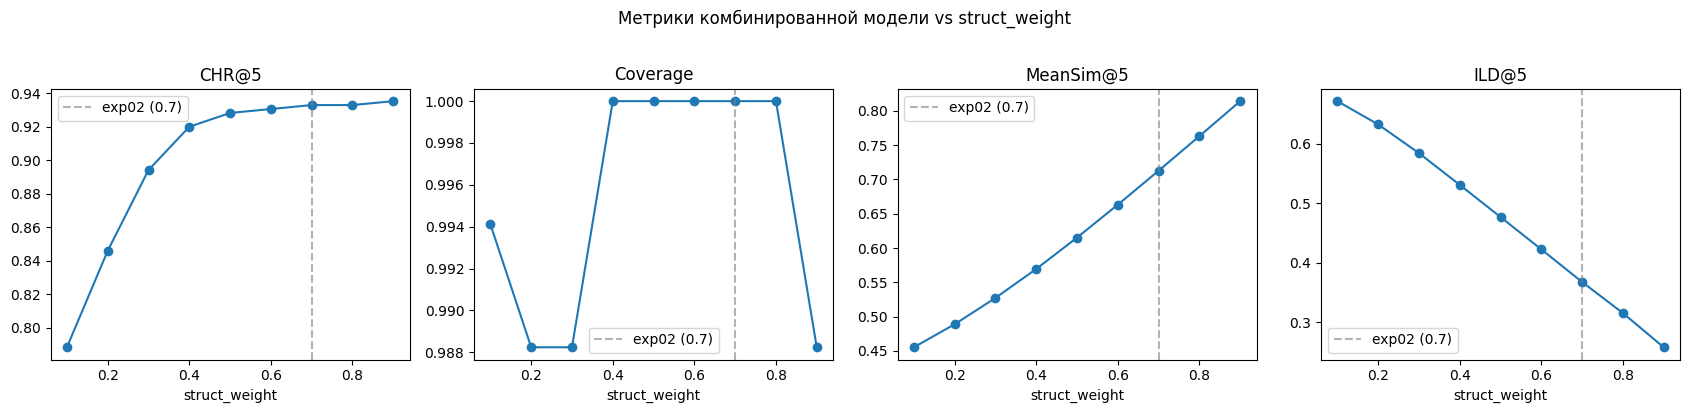

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, col in zip(axes, ["CHR@5", "Coverage", "MeanSim@5", "ILD@5"]):
    ax.plot(grid_df.index, grid_df[col], marker="o")
    ax.axvline(x=0.7, color="gray", linestyle="--", alpha=0.6, label="exp02 (0.7)")
    ax.set_xlabel("struct_weight")
    ax.set_title(col)
    ax.legend()

plt.suptitle("Метрики комбинированной модели vs struct_weight", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS / "10_weight_search.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Выбор оптимального веса

In [15]:
# Coverage=1.0 — жёсткое ограничение: каждый тур хотя бы раз появляется в рекомендациях.
# Среди кандидатов с одинаковым CHR (w=0.7 и w=0.8) выбираем максимальный ILD — больше разнообразия.
candidates = grid_df[grid_df["Coverage"] >= 1.0].copy()
best_w = float(
    candidates.sort_values(["CHR@5", "ILD@5"], ascending=[False, False]).index[0]
)

print(f"Оптимальный struct_weight: {best_w}")
print(f"  CHR@5    = {candidates.loc[best_w, 'CHR@5']:.3f}")
print(f"  Coverage = {candidates.loc[best_w, 'Coverage']:.3f}")
print(f"  MeanSim  = {candidates.loc[best_w, 'MeanSim@5']:.3f}")
print(f"  ILD@5    = {candidates.loc[best_w, 'ILD@5']:.3f}")

Оптимальный struct_weight: 0.7
  CHR@5    = 0.933
  Coverage = 1.000
  MeanSim  = 0.713
  ILD@5    = 0.368


In [16]:
# best_w — оптимальный: макс. CHR при Coverage=1.0, тайбрейкер по ILD
# alt_w  — наивный выбор по CHR без ограничения на покрытие (w=0.9)
alt_w = 0.9

sim_best = best_w * sim_struct + (1 - best_w) * sim_tfidf
sim_alt  = alt_w  * sim_struct + (1 - alt_w)  * sim_tfidf

comparison = pd.DataFrame([
    {
        "Модель":    f"w={best_w} (оптимальный, Coverage=1.0)",
        "CHR@5":     category_hit_rate(df, sim_best, TOP_K),
        "Coverage":  catalog_coverage(sim_best,      TOP_K),
        "MeanSim@5": mean_similarity(sim_best,       TOP_K),
        "ILD@5":     intra_list_diversity(sim_best,  TOP_K),
    },
    {
        "Модель":    f"w={alt_w}  (макс. CHR без огр. Coverage)",
        "CHR@5":     category_hit_rate(df, sim_alt,  TOP_K),
        "Coverage":  catalog_coverage(sim_alt,       TOP_K),
        "MeanSim@5": mean_similarity(sim_alt,        TOP_K),
        "ILD@5":     intra_list_diversity(sim_alt,   TOP_K),
    },
]).set_index("Модель").round(3)

display(comparison)
comparison.to_csv(ARTIFACTS / "model_comparison.csv")

,CHR@5,Coverage,MeanSim@5,ILD@5
Модель,,,,
"w=0.7 (оптимальный, Coverage=1.0)",0.933,1.000,0.713,0.368
w=0.9 (макс. CHR без огр. Coverage),0.935,0.988,0.814,0.258


---
## 5. Пример рекомендаций

In [17]:
query_tour = df[df["city_id"] == "barcelona"].iloc[0]
qid = query_tour["id"]
print(f"Запрос: {query_tour['name']} | {query_tour['category']} | €{query_tour['price']:.0f}")

print(f"\nw={best_w} — оптимальный, Coverage=1.000")
display(get_similar_tours(df, qid, sim_best))

print(f"\nw={alt_w} — макс. CHR без огр. Coverage, Coverage=0.988")
display(get_similar_tours(df, qid, sim_alt))

Запрос: Classic Barcelona — 6 nights | comfort | €1762

w=0.7 — оптимальный, Coverage=1.000


,name,city_name,category,hotel_stars,meal_type,price,similarity
0,Standard Barcelona — 5 nights,Barcelona,comfort,4,all_inclusive,1915.36,0.746
1,Standard Barcelona — 9 nights,Barcelona,comfort,4,all_inclusive,1757.37,0.736
2,Classic Barcelona — 8 nights,Barcelona,comfort,4,none,1328.15,0.588
3,Standard Barcelona — 8 nights,Barcelona,comfort,4,none,1163.71,0.586
4,Classic Paris — 6 nights,Paris,comfort,4,all_inclusive,1813.21,0.583



w=0.9 — макс. CHR без огр. Coverage, Coverage=0.988


,name,city_name,category,hotel_stars,meal_type,price,similarity
0,Standard Barcelona — 5 nights,Barcelona,comfort,4,all_inclusive,1915.36,0.914
1,Standard Barcelona — 9 nights,Barcelona,comfort,4,all_inclusive,1757.37,0.905
2,Classic New York — 8 nights,New York,comfort,4,all_inclusive,3376.01,0.667
3,Classic Paris — 6 nights,Paris,comfort,4,all_inclusive,1813.21,0.667
4,Classic Barcelona — 8 nights,Barcelona,comfort,4,none,1328.15,0.666


---
## 6. Сохранение артефактов

In [18]:
np.save(ARTIFACTS / "sim_combined.npy", sim_best)

with open(ARTIFACTS / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open(ARTIFACTS / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

df.to_json(ARTIFACTS / "tours_active.json", orient="records", force_ascii=False)

grid_df.to_csv(ARTIFACTS / "weight_search.csv")

(ARTIFACTS / "best_config.json").write_text(
    json.dumps({"struct_weight": best_w, "text_weight": round(1 - best_w, 1), "top_k": TOP_K}, indent=2)
)

print("Сохранено:", [p.name for p in sorted(ARTIFACTS.iterdir())])

Сохранено: ['10_weight_search.png', 'best_config.json', 'model_comparison.csv', 'scaler.pkl', 'sim_combined.npy', 'tfidf_vectorizer.pkl', 'tours_active.json', 'weight_search.csv']


---
## 7. Выводы

Grid search по `struct_weight` ∈ [0.1, 0.9] с ограничением Coverage = 1.0 подтверждает: **оптимальный вес — 0.7**, тот же, что использовался в `exp02_baseline.ipynb`.

| struct_weight | CHR@5 | Coverage | MeanSim@5 | ILD@5 |
|---|---|---|---|---|
| 0.5 | 0.928 | 1.000 | 0.615 | 0.477 |
| 0.6 | 0.931 | 1.000 | 0.663 | 0.423 |
| **0.7** | **0.933** | **1.000** | 0.713 | 0.368 |
| 0.8 | 0.933 | 1.000 | 0.763 | 0.315 |
| 0.9 | 0.935 | 0.988 | 0.814 | 0.258 |

При w = 0.9 CHR выше на 0.002, но Coverage падает до 0.988 — около 2 туров из 170 перестают появляться в рекомендациях. Такой трейдоф невыгоден: потеря покрытия видима пользователю, прирост качества статистически незначим.

При w < 0.6 Coverage стабильна на 1.0, но CHR проседает ниже 0.931 — TF-IDF вносит текстовый шум, размывающий ценовой сегмент.

ILD монотонно убывает с ростом `struct_weight` — структурная модель жёстче кластеризует туры. При w = 0.7 и w = 0.8 CHR и Coverage совпадают; ILD служит тайбрейкером: w = 0.7 даёт ILD = 0.368 против 0.315 у w = 0.8 — на 17% разнообразнее при том же качестве сегментации.

**Итог:** w = 0.7 обеспечивает максимальный CHR при Coverage = 1.0 и лучший ILD среди tied-кандидатов. Интуитивный выбор в exp02 подтверждён данными. Финальная модель `combined (w=0.7)` используется в сервисе без изменений.